# Chapter 6
## Data cleaning, Imbalanced Data, and Other Data Problems
This notebook is a companion to the book _XGBoost for Regression Predictive Modeling and Time Series Analysis_.
This chapter covers how to address common problems with real-life data sets and this code is a series of Python data cleaning functions.

In [4]:
# ----------------------------------------
# filename datacleaning.ipynb
# Python functions to perform common data cleaning tasks
# author Joyce Weiner
# revision 1.0
# revision history 1.0 - initial script
# ----------------------------------------

# These functions all use pandas
import pandas as pd
import numpy as np

In [5]:
# Create a test dataframe to use to verify the functions work correctly
testdf = pd.DataFrame(np.random.randn(5250,3), columns=list("ABC"))
testdf["category"] = "Category A"
testdf.loc[3000:4499,["category"]] = "CategoryB"  # Use .loc for slice assignment
testdf.loc[4500:5250,["category"]] = "Cat C"  # Use .loc for slice assignment
testdf.insert(len(testdf.columns),"Date",np.random.choice(pd.date_range('2022-10-01', '2024-11-30'),len(testdf)))
#testdf["Date"] = np.random.choice(pd.date_range('2022-10-01', '2023-10-31'), len(testdf))


In [6]:
import numpy

In [7]:
print(testdf)

             A         B         C    category       Date
0    -1.239138 -2.629487  0.355589  Category A 2024-09-20
1     0.462327 -0.153517 -0.699212  Category A 2024-10-19
2    -1.344797 -0.852695  0.912417  Category A 2022-12-16
3    -0.282458 -0.046972  1.837227  Category A 2024-07-27
4    -0.820435 -1.231197 -0.259803  Category A 2024-06-14
...        ...       ...       ...         ...        ...
5245 -0.015546 -0.098967  1.482773       Cat C 2024-04-21
5246 -0.946541 -1.658827 -0.244644       Cat C 2023-05-03
5247 -0.314818 -1.426052 -1.522160       Cat C 2023-12-09
5248  1.291651 -1.734488 -0.073212       Cat C 2022-12-24
5249 -0.503106  0.881365 -0.733664       Cat C 2023-08-07

[5250 rows x 5 columns]


## Example of multimodal data using the Iris dataset

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# load the iris data set from scikit-learn
from sklearn import datasets

irisarray = datasets.load_iris()# bring the array into a pandas dataframe and label the headers
# have to concatenate the data and the target -- which is already converted from words to numbers
irisdata = pd.DataFrame(np.c_[irisarray['data'], irisarray['target']], columns = irisarray['feature_names'] + ['Species'])
irisdata['Species'] = irisdata['Species'].astype(int)

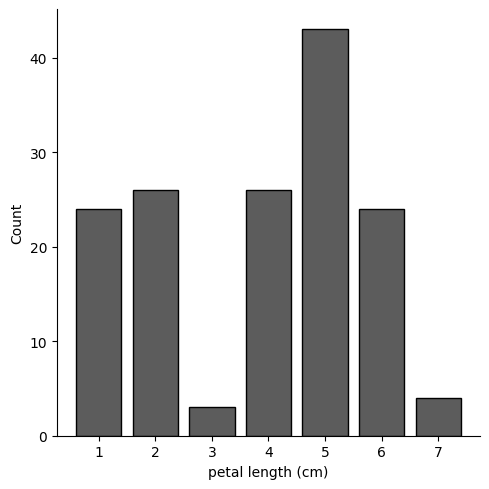

In [9]:
sns.set_palette("dark:grey")
sns.displot(irisdata, x="petal length (cm)", discrete = True, shrink =0.8)

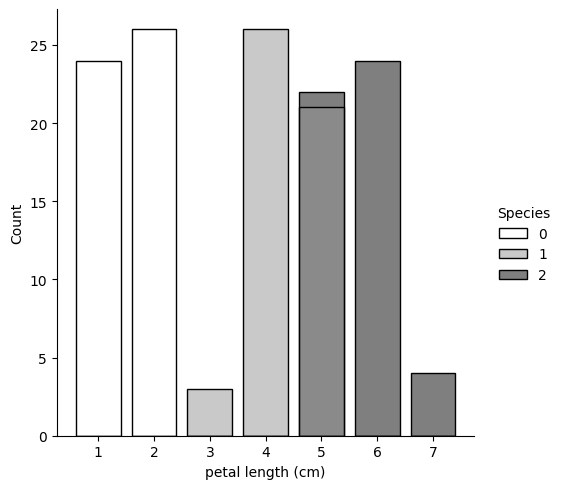

In [10]:
sns.displot(irisdata, x="petal length (cm)", discrete = True, hue = "Species", shrink =0.8, palette = "Greys")

### 4-pseudo sigma filter for continuous data

In [13]:
# Filter continuous data using a 4 pseudo sigma filter
# dataframe = pandas dataframe to modify
# parameter = name of column in dataframe to filter

def pseudosigmafilter(dataframe, parameter):
    mean = dataframe[parameter].mean()
    stdev = dataframe[parameter].std()
    lowerfiltervalue = mean - (4*stdev)
    upperfiltervalue = mean + (4*stdev)
    # print(mean)
    # print(stdev)
    # print(lowerfiltervalue)
    # print(upperfiltervalue)

    # Create a new column called "filter_" parameter and set to NaN if outside the limits
    dataframe["filter_" + parameter] = np.where(((dataframe[parameter] > lowerfiltervalue) & (dataframe[parameter] < upperfiltervalue)) , dataframe[parameter], np.nan)
    return dataframe

In [14]:
# Inject a huge value in Category A and test that it is filtered
testdf.at[0,"A"] = 11

pseudosigmafilter (testdf, "A")

,A,B,C,category,Date,filter_A
0,11.000000,-2.629487,0.355589,Category A,2024-09-20,NaN
1,0.462327,-0.153517,-0.699212,Category A,2024-10-19,0.462327
2,-1.344797,-0.852695,0.912417,Category A,2022-12-16,-1.344797
3,-0.282458,-0.046972,1.837227,Category A,2024-07-27,-0.282458
4,-0.820435,-1.231197,-0.259803,Category A,2024-06-14,-0.820435
...,...,...,...,...,...,...
5245,-0.015546,-0.098967,1.482773,Cat C,2024-04-21,-0.015546
5246,-0.946541,-1.658827,-0.244644,Cat C,2023-05-03,-0.946541
5247,-0.314818,-1.426052,-1.522160,Cat C,2023-12-09,-0.314818
5248,1.291651,-1.734488,-0.073212,Cat C,2022-12-24,1.291651


### Standardizing continuous data

In [15]:
from sklearn import preprocessing
continuous = testdf[["A", "B", "C"]]
continuous.head()


,A,B,C
0,11.000000,-2.629487,0.355589
1,0.462327,-0.153517,-0.699212
2,-1.344797,-0.852695,0.912417
3,-0.282458,-0.046972,1.837227
4,-0.820435,-1.231197,-0.259803


In [16]:
standardized = preprocessing.StandardScaler().fit(continuous)

In [17]:
standardized = standardized.transform(continuous)
print (standardized)

[[11.02105712 -2.64922614  0.34700027]
 [ 0.44366435 -0.14231232 -0.71142631]
 [-1.37027113 -0.85022837  0.90574266]
 ...
 [-0.33641017 -1.43075142 -1.53720232]
 [ 1.27611418 -1.74304211 -0.08327464]
 [-0.52540818  0.90550307 -0.74599643]]


In [18]:
standardizeddf = pd.DataFrame(standardized, columns=["A", "B", "C"] )
standardizeddf.head()

,A,B,C
0,11.021057,-2.649226,0.347000
1,0.443664,-0.142312,-0.711426
2,-1.370271,-0.850228,0.905743
3,-0.303928,-0.034436,1.833731
4,-0.843933,-1.233461,-0.270507


In [ ]:
standardizedtestdf = pd.concat([testdf, standardizeddf],axis=1)
standardizedtestdf.head()

,A,B,C,category,Date,filter_A,A,B,C
0,11.000000,1.873414,0.639126,Category A,2024-05-02,NaN,10.678286,1.886970,0.634187
1,0.693878,-1.267349,-0.048760,Category A,2022-10-24,0.693878,0.659415,-1.300350,-0.054584
2,-0.040755,0.741024,-0.151764,Category A,2024-07-17,-0.040755,-0.054742,0.737794,-0.157720
3,-0.192970,0.747340,0.042375,Category A,2024-01-03,-0.192970,-0.202715,0.744203,0.036668
4,-1.195458,-0.781590,0.430191,Category A,2024-10-28,-1.195458,-1.177262,-0.807390,0.424983


#### Centering data

In [ ]:
centered = preprocessing.StandardScaler(with_std=False).fit(continuous)
print(centered.transform(continuous))

[[10.984443    1.85940708  0.63337233]
 [ 0.67832096 -1.2813562  -0.05451375]
 [-0.05631191  0.72701668 -0.15751724]
 ...
 [-1.97426454  0.89272787  0.08976492]
 [ 0.87711538 -0.13235854  1.44136651]
 [-0.86401398 -0.69872778 -0.0748915 ]]


### Normalizing continuous data

In [ ]:
from sklearn import preprocessing
def normalizecolumn(dataframe, parameter):
    colarray = np.array(dataframe[parameter])
    normalizedarray = preprocessing.normalize([colarray]).tolist()
    normalizedarray = np.swapaxes(normalizedarray,0,1)
    dataframe["normalized_" + parameter] = normalizedarray
    return dataframe

In [ ]:
normalizecolumn(testdf, "B")

,A,B,C,category,Date,filter_A,normalized_B
0,11.000000,1.873414,0.639126,Category A,2024-05-02,NaN,0.026236
1,0.693878,-1.267349,-0.048760,Category A,2022-10-24,0.693878,-0.017749
2,-0.040755,0.741024,-0.151764,Category A,2024-07-17,-0.040755,0.010378
3,-0.192970,0.747340,0.042375,Category A,2024-01-03,-0.192970,0.010466
4,-1.195458,-0.781590,0.430191,Category A,2024-10-28,-1.195458,-0.010946
...,...,...,...,...,...,...,...
5245,-1.046118,1.509347,-0.556320,Cat C,2023-04-18,-1.046118,0.021138
5246,2.119105,-0.867327,0.068335,Cat C,2024-11-08,2.119105,-0.012146
5247,-1.958708,0.906735,0.095519,Cat C,2024-01-06,-1.958708,0.012698
5248,0.892672,-0.118352,1.447120,Cat C,2023-04-24,0.892672,-0.001657


### Correcting spelling in a column

In [ ]:
def cleancategory(dataframe, parameter):
    if parameter == "category":
        dataframe["clean_" + parameter] = "Category " + dataframe[parameter].str[-1]
    return dataframe

In [ ]:
cleancategory(testdf, "category" )

,A,B,C,category,Date,filter_A,normalized_B,clean_category
0,11.000000,1.873414,0.639126,Category A,2024-05-02,NaN,0.026236,Category A
1,0.693878,-1.267349,-0.048760,Category A,2022-10-24,0.693878,-0.017749,Category A
2,-0.040755,0.741024,-0.151764,Category A,2024-07-17,-0.040755,0.010378,Category A
3,-0.192970,0.747340,0.042375,Category A,2024-01-03,-0.192970,0.010466,Category A
4,-1.195458,-0.781590,0.430191,Category A,2024-10-28,-1.195458,-0.010946,Category A
...,...,...,...,...,...,...,...,...
5245,-1.046118,1.509347,-0.556320,Cat C,2023-04-18,-1.046118,0.021138,Category C
5246,2.119105,-0.867327,0.068335,Cat C,2024-11-08,2.119105,-0.012146,Category C
5247,-1.958708,0.906735,0.095519,Cat C,2024-01-06,-1.958708,0.012698,Category C
5248,0.892672,-0.118352,1.447120,Cat C,2023-04-24,0.892672,-0.001657,Category C


### Reformatting date data

In [ ]:
testdf["Date_new"] = testdf["Date"].dt.strftime("%d-%b-%Y")
testdf.head()

,A,B,C,category,Date,filter_A,normalized_B,clean_category,Date_new
0,11.000000,1.873414,0.639126,Category A,2024-05-02,NaN,0.026236,Category A,02-May-2024
1,0.693878,-1.267349,-0.048760,Category A,2022-10-24,0.693878,-0.017749,Category A,24-Oct-2022
2,-0.040755,0.741024,-0.151764,Category A,2024-07-17,-0.040755,0.010378,Category A,17-Jul-2024
3,-0.192970,0.747340,0.042375,Category A,2024-01-03,-0.192970,0.010466,Category A,03-Jan-2024
4,-1.195458,-0.781590,0.430191,Category A,2024-10-28,-1.195458,-0.010946,Category A,28-Oct-2024


In [ ]:
testdf["Date_US"] = testdf["Date"].dt.strftime("%m/%d/%Y")
testdf.head()

,A,B,C,category,Date,filter_A,normalized_B,clean_category,Date_new,Date_US
0,11.000000,1.873414,0.639126,Category A,2024-05-02,NaN,0.026236,Category A,02-May-2024,05/02/2024
1,0.693878,-1.267349,-0.048760,Category A,2022-10-24,0.693878,-0.017749,Category A,24-Oct-2022,10/24/2022
2,-0.040755,0.741024,-0.151764,Category A,2024-07-17,-0.040755,0.010378,Category A,17-Jul-2024,07/17/2024
3,-0.192970,0.747340,0.042375,Category A,2024-01-03,-0.192970,0.010466,Category A,03-Jan-2024,01/03/2024
4,-1.195458,-0.781590,0.430191,Category A,2024-10-28,-1.195458,-0.010946,Category A,28-Oct-2024,10/28/2024


### Sampling data for each class to match the class with the smallest number of observations

In [ ]:
# Use pandas to select a random sample by category
# dataframe = pandas dataframe to modify
# category = name of column in dataframe
# nsamples = number of rows

def subsamplecategory(olddataframe,category,nsamples):
    newdataframe = olddataframe.groupby(category).apply(lambda s: s.sample(nsamples))
    return newdataframe

In [ ]:
newdf = subsamplecategory(testdf,"category",750)
print (newdf)

                       A         B         C   category       Date  filter_A  \
category                                                                       
Cat C     4979  0.802537  0.800369  0.078219      Cat C 2023-12-05  0.802537   
          5235  0.295449 -0.360807  0.140995      Cat C 2023-09-29  0.295449   
          5029  0.535208  3.494783 -0.599452      Cat C 2023-12-09  0.535208   
          4895 -1.254495  0.462313  0.701660      Cat C 2023-06-01 -1.254495   
          4530  0.551671  1.658620 -0.178928      Cat C 2024-03-13  0.551671   
...                  ...       ...       ...        ...        ...       ...   
CategoryB 3289 -0.427420  0.211272  1.091192  CategoryB 2022-10-25 -0.427420   
          4008 -0.209445  1.296175  0.261754  CategoryB 2023-04-03 -0.209445   
          3092 -0.832112  1.472123 -0.235077  CategoryB 2023-10-07 -0.832112   
          3119  0.548525 -0.294176  0.583786  CategoryB 2023-10-10  0.548525   
          3342  0.874167  0.643727  2.43

<ipython-input-21-014c61833303>:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  newdataframe = olddataframe.groupby(category).apply(lambda s: s.sample(nsamples))
